=== Lab coverage periods ===
# A tibble: 4 × 5
  source first_date last_date  n_dates n_obs
  <chr>  <date>     <date>       <int> <int>
1 BBRS   1995-12-13 1998-04-21      31   246
2 MOTE   1998-06-09 2001-07-10      38   307
3 HPL    2006-07-04 2010-12-08      51   478
4 NGSFC  2011-01-11 2017-01-12      56   567


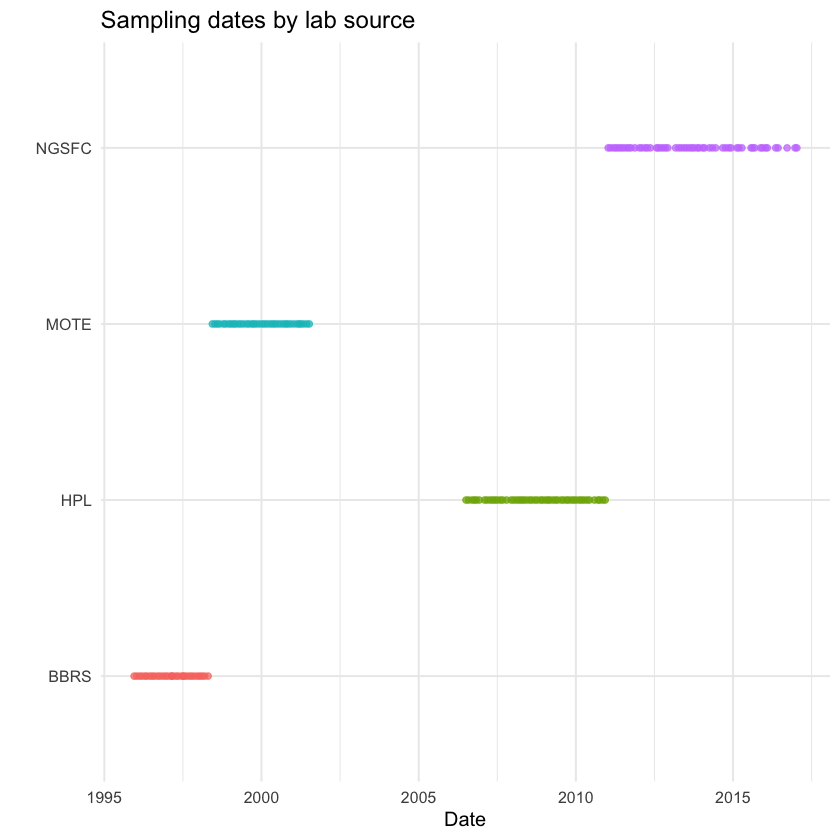

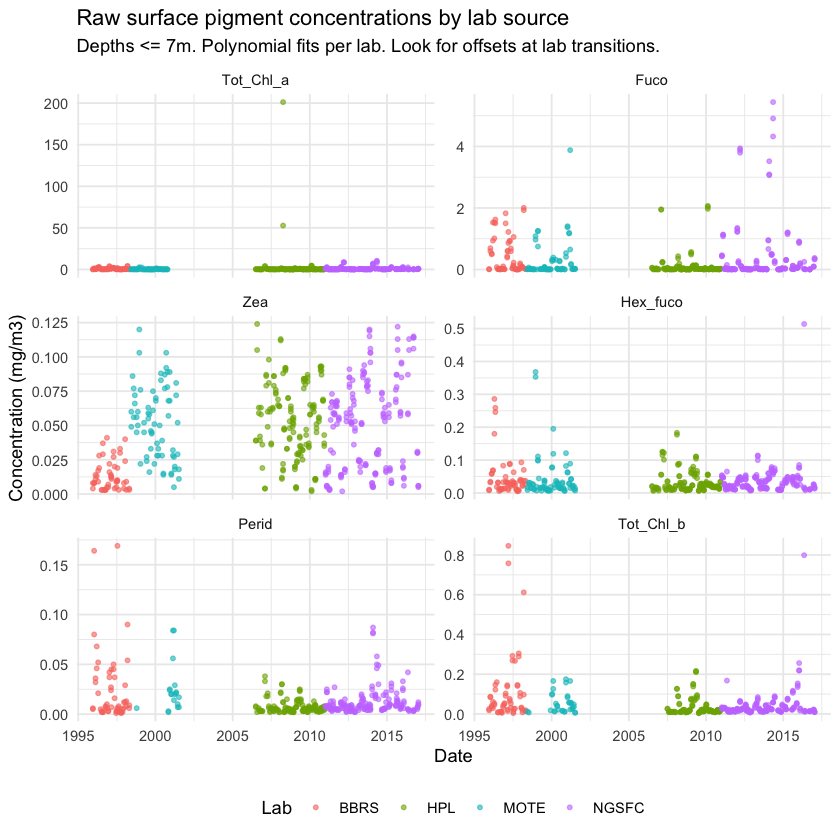


=== Dates with overlapping lab measurements: 0 ===
No overlapping dates between labs.

=== Lab transitions ===
# A tibble: 3 × 4
  source last_date  next_source next_start
  <chr>  <date>     <chr>       <date>    
1 BBRS   1998-04-21 MOTE        1998-06-09
2 MOTE   2001-07-10 HPL         2006-07-04
3 HPL    2010-12-08 NGSFC       2011-01-11

=== Mean pigment concentrations around lab transitions (upper 25m) ===
  Tot_Chl_a       Fuco        Zea   Hex_fuco       Perid  Tot_Chl_b
1 0.8054583 0.30791667 0.01364286 0.05129167 0.021375000 0.14845833
2 0.2333750 0.02486364 0.06087500 0.03900000 0.011666667 0.04262500
3       NaN 0.77067857 0.03153571 0.04439286 0.035750000 0.06539286
4 0.2148800 0.01952000 0.05552000 0.02108000 0.006916667        NaN
5 0.2465000 0.03128571 0.06914286 0.03028571 0.005785714 0.02992857
6 1.0006667 0.36423077 0.02817949 0.03905128 0.013794872 0.06405556
             period   transition
1   BBRS (last 6mo) BBRS -> MOTE
2  MOTE (first 6mo) BBRS -> MOTE
3   MOTE

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_col()`).”


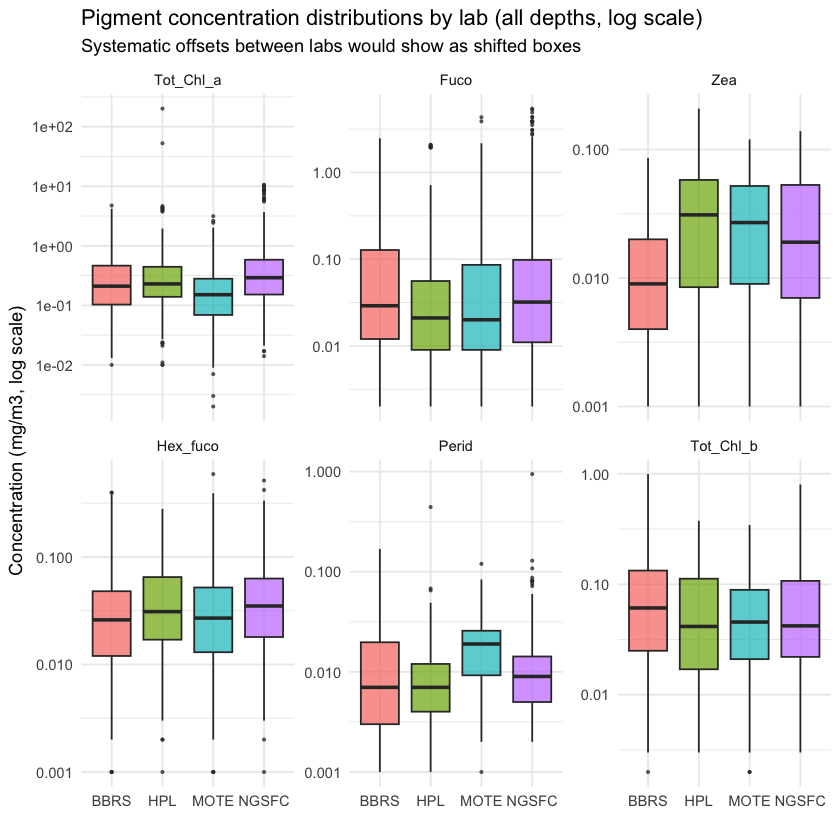

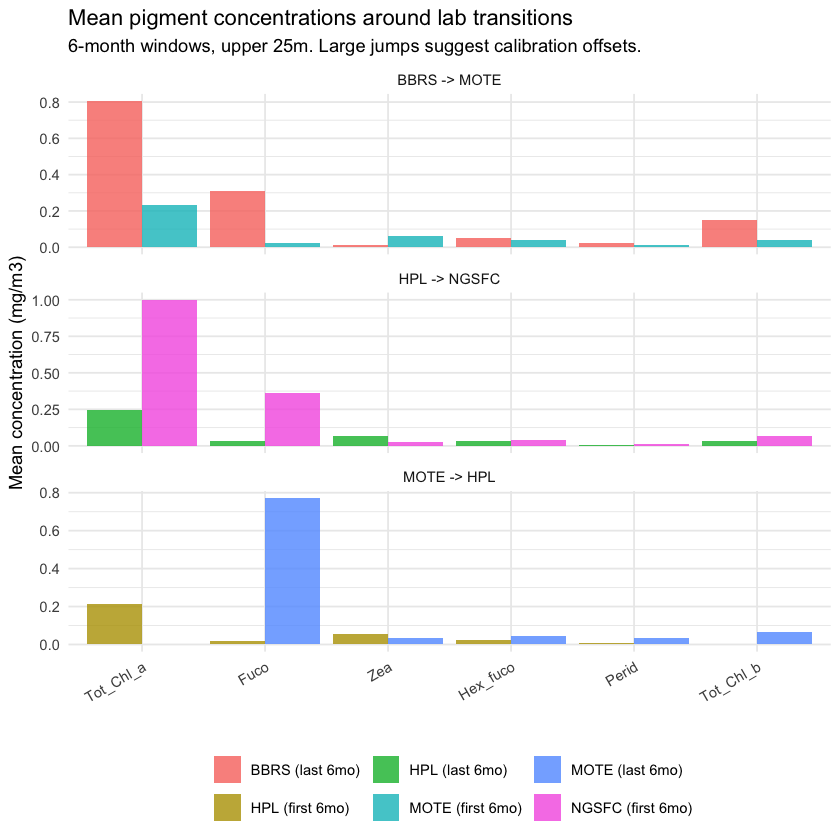


--- Ratio summary statistics by lab ---
# A tibble: 4 × 17
  ratio      median_BBRS median_HPL median_MOTE median_NGSFC mean_BBRS mean_HPL
  <chr>            <dbl>      <dbl>       <dbl>        <dbl>     <dbl>    <dbl>
1 ChlB_TChla      0.0931     0.0959      0.122        0.097     0.262     0.114
2 Fuco_TChla      0.316      0.0591      0.0885       0.0886    0.337     0.114
3 HexF_TChla      0.0811     0.105       0.137        0.0885    0.0922    0.107
4 Zea_TChla       0.0177     0.248       0.301        0.129     0.043     0.260
  mean_MOTE mean_NGSFC sd_BBRS sd_HPL sd_MOTE sd_NGSFC n_BBRS n_HPL n_MOTE
      <dbl>      <dbl>   <dbl>  <dbl>   <dbl>    <dbl>  <int> <int>  <int>
1     0.146     0.107   0.388  0.0674  0.0836   0.0795    115   204     41
2     0.212     0.185   0.340  0.128   0.348    0.17      124   252     94
3     0.214     0.0908  0.0607 0.0441  0.364    0.0506    123   252    107
4     0.371     0.203   0.0648 0.192   0.290    0.197     102   249    102
# ℹ 1 more

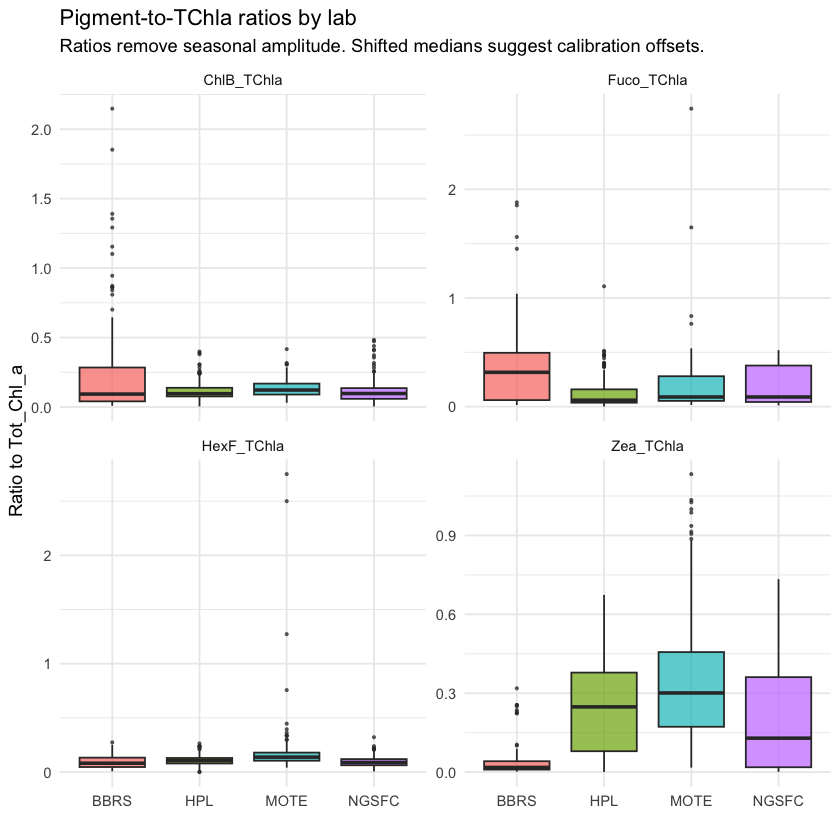

In [2]:
library(tidyverse)
library(patchwork)

# =============================================================================
# 1. LOAD RAW DATA (before interpolation, to see actual measured values)
# =============================================================================

hplc_bbrs  <- read.csv("../BCO-DMO/hplc_bbrs.csv", na.strings = "nd")
hplc_mote  <- read.csv("../BCO-DMO/hplc_mote.csv", na.strings = "nd")
hplc_hpl   <- read.csv("../BCO-DMO/hplc_hpl.csv", na.strings = "nd")
hplc_ngsfc <- read.csv("../BCO-DMO/hplc_ngsfc.csv", na.strings = "nd")

hplc_bbrs$source  <- "BBRS"
hplc_mote$source  <- "MOTE"
hplc_hpl$source   <- "HPL"
hplc_ngsfc$source <- "NGSFC"

pigments <- c("Pras", "Lut", "Fuco", "Perid", "Allo", "But_fuco",
              "Hex_fuco", "Zea", "Tot_Chl_b", "Tot_Chl_a", "Chl_c1c2", "Chl_c3")

fulldat <- c(pigments, "Date", "depth", "source")

HPLC_ds <- rbind(hplc_bbrs[fulldat],
                 hplc_mote[fulldat],
                 hplc_hpl[fulldat],
                 hplc_ngsfc[fulldat])

HPLC_ds$date <- as.Date(as.character(HPLC_ds$Date), format = "%Y%m%d")
HPLC_ds <- HPLC_ds %>% select(-Date)
HPLC_ds[pigments][HPLC_ds[pigments] < 0] <- NA

# =============================================================================
# 2. WHICH LABS COVER WHICH TIME PERIODS?
# =============================================================================

lab_periods <- HPLC_ds %>%
  group_by(source) %>%
  summarise(first_date = min(date), last_date = max(date),
            n_dates = n_distinct(date), n_obs = n(), .groups = "drop") %>%
  arrange(first_date)

cat("=== Lab coverage periods ===\n")
print(lab_periods)

# Timeline showing lab coverage
p_timeline <- HPLC_ds %>%
  distinct(date, source) %>%
  ggplot(aes(x = date, y = source, color = source)) +
  geom_point(size = 1.5, alpha = 0.7) +
  labs(title = "Sampling dates by lab source",
       x = "Date", y = "") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none")

print(p_timeline)

# =============================================================================
# 3. KEY PIGMENT TIME SERIES COLORED BY SOURCE
# =============================================================================

key_pigments <- c("Tot_Chl_a", "Fuco", "Zea", "Hex_fuco", "Perid", "Tot_Chl_b")

# Use surface (1m) measurements for clearest comparison
raw_surface <- HPLC_ds %>%
  filter(depth <= 7) %>%  # 1m and 7m - surface layer
  select(date, depth, source, all_of(key_pigments)) %>%
  pivot_longer(cols = all_of(key_pigments), names_to = "pigment", values_to = "concentration") %>%
  filter(!is.na(concentration))

p_ts_by_source <- raw_surface %>%
  mutate(pigment = factor(pigment, levels = key_pigments)) %>%
  ggplot(aes(x = date, y = concentration, color = source)) +
  geom_point(size = 1, alpha = 0.6) +
  #geom_smooth(method = "lm", formula = y ~ poly(x, 3), se = FALSE, linewidth = 0.7) +
  facet_wrap(~pigment, scales = "free_y", ncol = 2) +
  labs(title = "Raw surface pigment concentrations by lab source",
       subtitle = "Depths <= 7m. Polynomial fits per lab. Look for offsets at lab transitions.",
       x = "Date", y = "Concentration (mg/m3)", color = "Lab") +
  theme_minimal(base_size = 11) +
  theme(legend.position = "bottom")

print(p_ts_by_source)

# =============================================================================
# 4. BOXPLOTS BY SOURCE (depth-normalized to reduce depth effects)
#    Compare distributions controlling for depth
# =============================================================================

# Use all depths but facet by pigment
raw_long <- HPLC_ds %>%
  select(date, depth, source, all_of(key_pigments)) %>%
  pivot_longer(cols = all_of(key_pigments), names_to = "pigment", values_to = "concentration") %>%
  filter(!is.na(concentration), concentration > 0) %>%
  mutate(pigment = factor(pigment, levels = key_pigments))

p_boxplot <- raw_long %>%
  ggplot(aes(x = source, y = concentration, fill = source)) +
  geom_boxplot(outlier.size = 0.5, alpha = 0.7) +
  scale_y_log10() +
  facet_wrap(~pigment, scales = "free_y", ncol = 3) +
  labs(title = "Pigment concentration distributions by lab (all depths, log scale)",
       subtitle = "Systematic offsets between labs would show as shifted boxes",
       x = "", y = "Concentration (mg/m3, log scale)") +
  theme_minimal(base_size = 11) +
  theme(legend.position = "none")

print(p_boxplot)

# =============================================================================
# 5. DEPTH PROFILE COMPARISON AT OVERLAPPING PERIODS
#    If two labs overlap in time, compare their profiles directly
# =============================================================================

# Find dates where multiple labs sampled
overlap_dates <- HPLC_ds %>%
  distinct(date, source) %>%
  group_by(date) %>%
  filter(n_distinct(source) > 1) %>%
  pull(date) %>% unique()

cat(sprintf("\n=== Dates with overlapping lab measurements: %d ===\n", length(overlap_dates)))

if (length(overlap_dates) > 0) {
  overlap_data <- HPLC_ds %>%
    filter(date %in% overlap_dates) %>%
    select(date, depth, source, all_of(key_pigments))
  
  cat("Overlap dates:\n")
  print(overlap_data %>% distinct(date, source) %>% arrange(date))
  
  # Plot overlapping profiles
  overlap_long <- overlap_data %>%
    pivot_longer(cols = all_of(key_pigments), names_to = "pigment", values_to = "concentration") %>%
    filter(!is.na(concentration))
  
  if (nrow(overlap_long) > 0) {
    p_overlap <- overlap_long %>%
      mutate(pigment = factor(pigment, levels = key_pigments)) %>%
      ggplot(aes(x = concentration, y = -depth, color = source)) +
      geom_point() +
      geom_line() +
      facet_grid(date ~ pigment, scales = "free_x") +
      labs(title = "Depth profiles on overlapping dates",
           x = "Concentration (mg/m3)", y = "Depth (m)", color = "Lab") +
      theme_minimal(base_size = 10)
    
    print(p_overlap)
  }
} else {
  cat("No overlapping dates between labs.\n")
}

# =============================================================================
# 6. TRANSITION ANALYSIS: compare means in windows around lab changes
# =============================================================================

# Identify transition dates (last date of one lab, first date of next)
transitions <- lab_periods %>%
  arrange(first_date) %>%
  mutate(next_source = lead(source),
         next_start = lead(first_date)) %>%
  filter(!is.na(next_source))

cat("\n=== Lab transitions ===\n")
print(transitions %>% select(source, last_date, next_source, next_start))

# For each transition, compare pigment means in a window around the switch
window_days <- 180  # 6 months before/after transition

transition_stats <- list()

for (i in 1:nrow(transitions)) {
  t_date <- transitions$last_date[i]  # approximate transition point
  lab_before <- transitions$source[i]
  lab_after  <- transitions$next_source[i]
  
  before <- HPLC_ds %>%
    filter(source == lab_before,
           date >= t_date - window_days & date <= t_date,
           depth <= 25) %>%
    select(all_of(key_pigments)) %>%
    summarise(across(everything(), ~mean(.x, na.rm = TRUE))) %>%
    mutate(period = paste0(lab_before, " (last 6mo)"))
  
  after <- HPLC_ds %>%
    filter(source == lab_after,
           date >= transitions$next_start[i] & date <= transitions$next_start[i] + window_days,
           depth <= 25) %>%
    select(all_of(key_pigments)) %>%
    summarise(across(everything(), ~mean(.x, na.rm = TRUE))) %>%
    mutate(period = paste0(lab_after, " (first 6mo)"))
  
  transition_stats[[i]] <- bind_rows(before, after) %>%
    mutate(transition = paste(lab_before, "->", lab_after))
}

if (length(transition_stats) > 0) {
  trans_df <- bind_rows(transition_stats)
  
  cat("\n=== Mean pigment concentrations around lab transitions (upper 25m) ===\n")
  print(trans_df)
  
  # Plot as grouped bars
  trans_long <- trans_df %>%
    pivot_longer(cols = all_of(key_pigments), names_to = "pigment", values_to = "mean_conc") %>%
    mutate(pigment = factor(pigment, levels = key_pigments))
  
  p_transition <- trans_long %>%
    ggplot(aes(x = pigment, y = mean_conc, fill = period)) +
    geom_col(position = "dodge", alpha = 0.8) +
    facet_wrap(~transition, ncol = 1, scales = "free_y") +
    labs(title = "Mean pigment concentrations around lab transitions",
         subtitle = paste0("6-month windows, upper 25m. Large jumps suggest calibration offsets."),
         x = "", y = "Mean concentration (mg/m3)", fill = "") +
    theme_minimal(base_size = 11) +
    theme(axis.text.x = element_text(angle = 30, hjust = 1),
          legend.position = "bottom")
  
  print(p_transition)
}

# =============================================================================
# 7. PIGMENT RATIOS - more robust to seasonal variation
#    Ratios between pigments should be relatively stable across labs
#    if calibration is consistent
# =============================================================================

ratio_df <- HPLC_ds %>%
  filter(depth <= 25, Tot_Chl_a > 0.01) %>%  # surface, avoid near-zero
  mutate(
    Fuco_TChla   = Fuco / Tot_Chl_a,
    Zea_TChla    = Zea / Tot_Chl_a,
    HexF_TChla   = Hex_fuco / Tot_Chl_a,
    ChlB_TChla   = Tot_Chl_b / Tot_Chl_a
  ) %>%
  select(date, source, Fuco_TChla, Zea_TChla, HexF_TChla, ChlB_TChla) %>%
  pivot_longer(cols = c(Fuco_TChla, Zea_TChla, HexF_TChla, ChlB_TChla),
               names_to = "ratio", values_to = "value") %>%
  filter(!is.na(value), is.finite(value), value < 5)  # remove extreme outliers

p_ratios <- ratio_df %>%
  ggplot(aes(x = source, y = value, fill = source)) +
  geom_boxplot(outlier.size = 0.5, alpha = 0.7) +
  facet_wrap(~ratio, scales = "free_y") +
  labs(title = "Pigment-to-TChla ratios by lab",
       subtitle = "Ratios remove seasonal amplitude. Shifted medians suggest calibration offsets.",
       x = "", y = "Ratio to Tot_Chl_a") +
  theme_minimal(base_size = 11) +
  theme(legend.position = "none")

print(p_ratios)

cat("\n--- Ratio summary statistics by lab ---\n")
ratio_df %>%
  group_by(source, ratio) %>%
  summarise(median = round(median(value, na.rm = TRUE), 4),
            mean   = round(mean(value, na.rm = TRUE), 4),
            sd     = round(sd(value, na.rm = TRUE), 4),
            n      = n(), .groups = "drop") %>%
  pivot_wider(names_from = source, values_from = c(median, mean, sd, n)) %>%
  print(width = 120)

cat("\nDone. Key things to look for:\n")
cat("- Shifted boxes in pigment ratios (plot 7) = calibration offset\n")
cat("- Step changes at transitions (plot 6) not explained by seasonality\n")
cat("- Systematically different LOESS curves for same time period (plot 3)\n")